# Marketing Analytics Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [3]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

campaigns = pd.read_csv(RAW_DATA_DIR / "campaigns.csv")
customers = pd.read_csv(RAW_DATA_DIR / "customers.csv")
products = pd.read_csv(RAW_DATA_DIR / "products.csv")
events = pd.read_csv(RAW_DATA_DIR / "events.csv")
transactions = pd.read_csv(RAW_DATA_DIR / "transactions.csv")

## Campaigns Table

In [4]:
campaigns.head()

,campaign_id,channel,objective,start_date,end_date,target_segment,expected_uplift
0,1,Paid Search,Cross-sell,2021-10-25,2021-11-26,Deal Seekers,0.022
1,2,Email,Retention,2021-10-24,2021-12-24,Deal Seekers,0.116
2,3,Email,Reactivation,2023-10-08,2023-11-30,Churn Risk,0.100
3,4,Display,Reactivation,2022-07-25,2022-10-07,Deal Seekers,0.111
4,5,Social,Acquisition,2022-07-09,2022-09-29,New Customers,0.144


In [7]:
campaigns.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   campaign_id      50 non-null     int64  
 1   channel          50 non-null     str    
 2   objective        50 non-null     str    
 3   start_date       50 non-null     str    
 4   end_date         50 non-null     str    
 5   target_segment   50 non-null     str    
 6   expected_uplift  50 non-null     float64
dtypes: float64(1), int64(1), str(5)
memory usage: 2.9 KB


In [10]:
campaigns.isna().sum().sort_values(ascending=False)

campaign_id        0
channel            0
objective          0
start_date         0
end_date           0
target_segment     0
expected_uplift    0
dtype: int64

In [6]:
campaigns.nunique()

campaign_id        50
channel             5
objective           4
start_date         49
end_date           48
target_segment      5
expected_uplift    43
dtype: int64

In [15]:
campaigns.duplicated().sum()

np.int64(0)

In [4]:
campaigns.columns.tolist()

['campaign_id',
 'channel',
 'objective',
 'start_date',
 'end_date',
 'target_segment',
 'expected_uplift']

In [5]:
campaigns.duplicated(
    subset=[
        "channel",
        "objective",
        "start_date",
        "end_date",
        "target_segment",
        "expected_uplift",
    ]
).sum()

np.int64(0)

In [ ]:
campaigns.describe(include="all")

,campaign_id,channel,objective,start_date,end_date,target_segment,expected_uplift
count,50.00000,50,50,50,50,50,50.000000
unique,NaN,5,4,49,48,5,NaN
top,NaN,Paid Search,Reactivation,2022-07-25,2022-09-29,New Customers,NaN
freq,NaN,11,15,2,2,12,NaN
mean,25.50000,NaN,NaN,NaN,NaN,NaN,0.086660
std,14.57738,NaN,NaN,NaN,NaN,NaN,0.035854
min,1.00000,NaN,NaN,NaN,NaN,NaN,0.022000
25%,13.25000,NaN,NaN,NaN,NaN,NaN,0.057250
50%,25.50000,NaN,NaN,NaN,NaN,NaN,0.092500
75%,37.75000,NaN,NaN,NaN,NaN,NaN,0.113750


In [16]:
campaigns.nunique()

campaign_id        50
channel             5
objective           4
start_date         49
end_date           48
target_segment      5
expected_uplift    43
dtype: int64

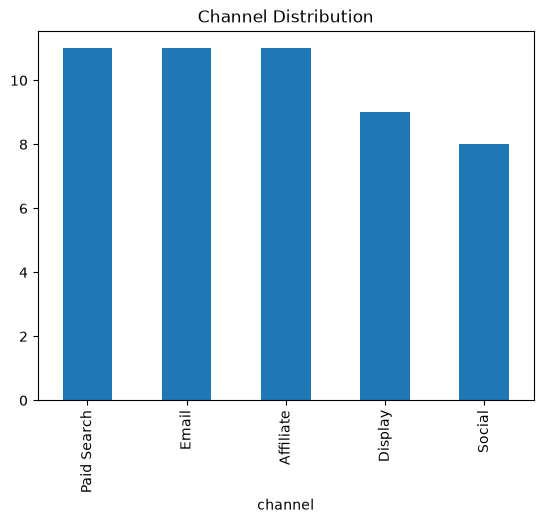

In [ ]:
campaigns["channel"].value_counts().plot(kind="bar", title="Channel Distribution")
plt.show()

In [10]:
campaigns["channel"].value_counts(normalize=True) * 100

channel
Paid Search    22.0
Email          22.0
Affiliate      22.0
Display        18.0
Social         16.0
Name: proportion, dtype: float64

<Axes: xlabel='objective', ylabel='count'>

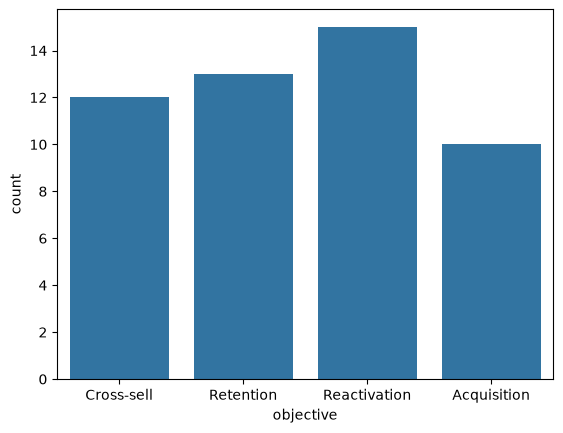

In [37]:
sns.countplot(data=campaigns, x="objective")

In [11]:
campaigns["objective"].value_counts(normalize=True) * 100

objective
Reactivation    30.0
Retention       26.0
Cross-sell      24.0
Acquisition     20.0
Name: proportion, dtype: float64

<Axes: xlabel='target_segment', ylabel='count'>

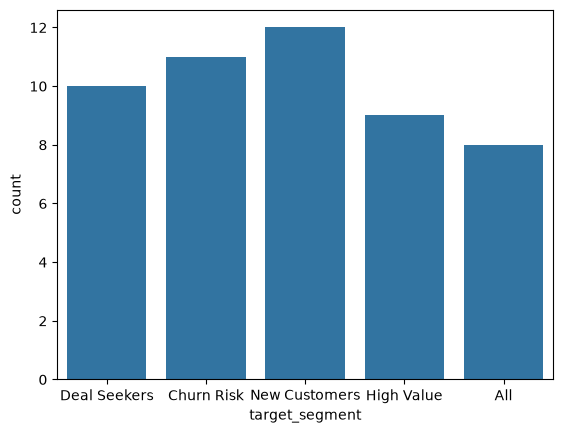

In [38]:
sns.countplot(data=campaigns, x="target_segment")

In [12]:
campaigns["target_segment"].value_counts(normalize=True) * 100

target_segment
New Customers    24.0
Churn Risk       22.0
Deal Seekers     20.0
High Value       18.0
All              16.0
Name: proportion, dtype: float64

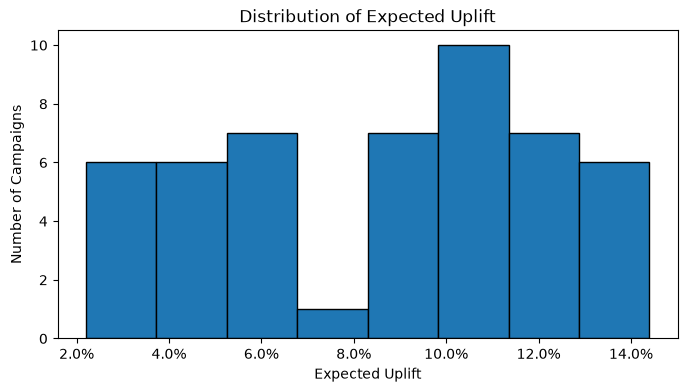

In [13]:
plt.figure(figsize=(8, 4))

plt.hist(campaigns["expected_uplift"], bins=8, edgecolor="black")

plt.gca().xaxis.set_major_formatter(PercentFormatter(1))

plt.title("Distribution of Expected Uplift")
plt.xlabel("Expected Uplift")
plt.ylabel("Number of Campaigns")

plt.show()

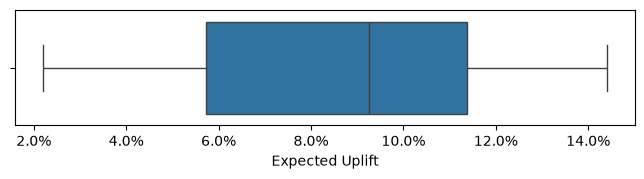

In [ ]:
plt.figure(figsize=(8, 1.5))

sns.boxplot(x=campaigns["expected_uplift"])

plt.gca().xaxis.set_major_formatter(PercentFormatter(1))

plt.xlabel("Expected Uplift")

plt.show()

In [13]:
campaigns["expected_uplift"].describe()

count    50.000000
mean      0.086660
std       0.035854
min       0.022000
25%       0.057250
50%       0.092500
75%       0.113750
max       0.144000
Name: expected_uplift, dtype: float64

In [8]:
campaigns.groupby("channel")["expected_uplift"].mean().sort_values()

channel
Social         0.074125
Email          0.074909
Display        0.089111
Paid Search    0.093545
Affiliate      0.098636
Name: expected_uplift, dtype: float64

In [9]:
campaigns.groupby("objective")["expected_uplift"].mean().sort_values()

objective
Reactivation    0.084067
Acquisition     0.084600
Cross-sell      0.085167
Retention       0.092615
Name: expected_uplift, dtype: float64

In [10]:
campaigns.groupby("target_segment")["expected_uplift"].mean().sort_values()

target_segment
Churn Risk       0.071000
Deal Seekers     0.086400
High Value       0.088444
New Customers    0.094000
All              0.095500
Name: expected_uplift, dtype: float64

In [16]:
campaigns["start_date"] = pd.to_datetime(campaigns["start_date"])
campaigns["end_date"] = pd.to_datetime(campaigns["end_date"])

In [32]:
campaigns["start_date"].min()

Timestamp('2021-01-20 00:00:00')

In [27]:
campaigns["start_date"].max()

Timestamp('2023-11-04 00:00:00')

In [31]:
campaigns["end_date"].min()

Timestamp('2021-02-21 00:00:00')

In [33]:
campaigns["end_date"].max()

Timestamp('2024-01-06 00:00:00')

In [ ]:
campaigns["duration_days"] = (campaigns["end_date"] - campaigns["start_date"]).dt.days

In [18]:
campaigns["duration_days"].describe()

count    50.000000
mean     50.980000
std      22.824521
min       8.000000
25%      37.250000
50%      54.000000
75%      68.000000
max      89.000000
Name: duration_days, dtype: float64

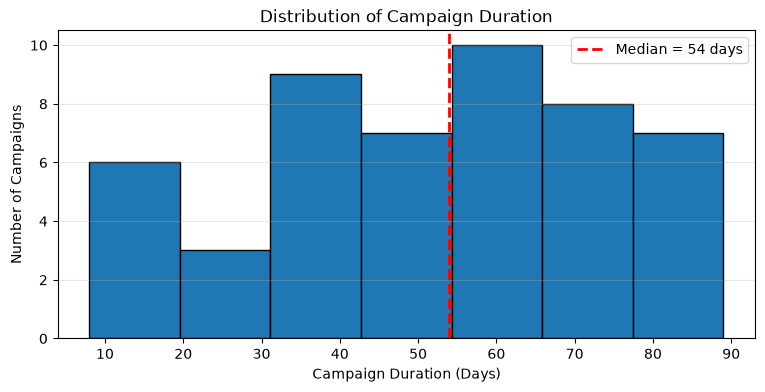

In [26]:
median = campaigns["duration_days"].median()

plt.figure(figsize=(9, 4))

plt.hist(campaigns["duration_days"], bins=7, edgecolor="black")

plt.axvline(
    median,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median:.0f} days",
)

plt.title("Distribution of Campaign Duration")
plt.xlabel("Campaign Duration (Days)")
plt.ylabel("Number of Campaigns")


plt.xticks(range(10, 91, 10))
plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.show()

In [27]:
campaigns["start_date"].dt.year.value_counts().sort_index()

start_date
2021    16
2022    18
2023    16
Name: count, dtype: int64

In [ ]:
pd.crosstab(campaigns["channel"], campaigns["objective"])

objective,Acquisition,Cross-sell,Reactivation,Retention
channel,,,,
Affiliate,2,2,4,3
Display,2,2,3,2
Email,3,1,4,3
Paid Search,1,6,2,2
Social,2,1,2,3


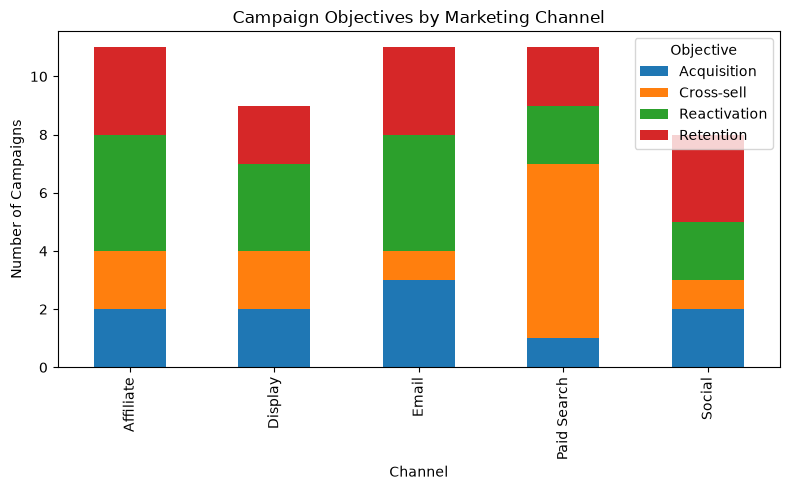

In [ ]:
cross_tab = pd.crosstab(campaigns["channel"], campaigns["objective"])

cross_tab.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.title("Campaign Objectives by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Campaigns")
plt.legend(title="Objective")
plt.tight_layout()
plt.show()

## Campaigns Table Overview

### Table Summary

The `campaigns` table contains information on **50 marketing campaigns**, including campaign dates, marketing channel, campaign objective, target customer segment, and expected performance (`expected_uplift`). Each record represents a unique campaign.

**Rows:** 50 
**Columns:** 7 
**Primary Key:** `campaign_id`

### Column Summary

- `campaign_id`: 50 unique campaign IDs.
- `channel`: Paid Search, Email, Affiliate, Display, Social.
- `objective`: Acquisition, Cross-sell, Reactivation, Retention.
- `target_segment`: All, Churn Risk, Deal Seekers, High Value, New Customers.
- `start_date`: 2021-01-20 to 2023-11-04.
- `end_date`: 2021-02-02 to 2024-01-06.
- `expected_uplift`: 2.2% to 14.4%.

### Duplicates
- The dataset contains **50 campaigns** and **50 unique `campaign_id` values**, confirming there are no duplicate primary keys.
- Excluding `campaign_id`, no duplicate records were identified.

### Missing Values
- No missing values were identified in the campaign dataset.

### Data Types
- `start_date` and `end_date` are stored as strings (`object`) rather than datetimes.
- Both columns will be converted to datetime during data cleaning.

### Channel Distribution
- Campaigns are relatively evenly distributed across marketing channels.
- Paid Search, Email, and Affiliate are the most common channels, each accounting for approximately **22%** of campaigns, followed by Display (**18%**) and Social (**16%**).

### Campaign Objective
- Campaign objectives are fairly balanced across the dataset.
- Reactivation is the most common campaign objective (**30%**), while Acquisition is the least common (**20%**).

### Target Segment
- Campaigns target a diverse range of customer segments.
- New Customers are the most frequently targeted segment (**24%**), followed by Churn Risk (**22%**), Deal Seekers (**20%**), High Value (**18%**), and All Customers (**16%**).

### Channel vs. Campaign Objective
- Campaign objectives are generally well distributed across marketing channels.
- **Paid Search** is the only channel with a noticeable preference for a single objective, with **Cross-sell** campaigns accounting for over half of all Paid Search campaigns.
- **Email**, **Affiliate**, **Display**, and **Social** campaigns have relatively balanced distributions across objectives, with only a slight preference for **Reactivation** (Email, Affiliate, Display) and **Retention** (Social).

### Expected Uplift
- Expected campaign uplift ranges from approximately **2% to 14%**, with a median of **9%**.
- Average expected uplift varies only modestly across campaign characteristics:
  - **Channel:** 7–10%
  - **Objective:** 8–9%
  - **Target Segment:** 7–10%
- Overall, differences in expected uplift are relatively small (approximately **2–3 percentage points**) across campaign characteristics.

### Duration
- Campaign durations range from **8 to 89 days**, with a median duration of **54 days**.
- Most campaigns run between **40 and 70 days**.

### Summary
The `campaigns` table is complete and well structured, requiring only date type conversions during data cleaning. Campaigns are relatively evenly distributed across channels, objectives, and target segments, making the dataset well suited for downstream performance analysis.

## Customers Table

In [5]:
customers.head()

,customer_id,signup_date,country,age,gender,loyalty_tier,acquisition_channel
0,1,2021-04-08,BR,48,Male,Bronze,Referral
1,2,2023-04-28,IN,36,Female,Silver,Organic
2,3,2022-12-18,UK,35,Female,Silver,Organic
3,4,2022-04-26,US,45,Male,Silver,Paid Search
4,5,2022-04-20,IN,53,Male,Silver,Organic


In [6]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   customer_id          100000 non-null  int64
 1   signup_date          100000 non-null  str  
 2   country              100000 non-null  str  
 3   age                  100000 non-null  int64
 4   gender               100000 non-null  str  
 5   loyalty_tier         100000 non-null  str  
 6   acquisition_channel  100000 non-null  str  
dtypes: int64(2), str(5)
memory usage: 5.3 MB


In [ ]:
customers.describe(include="all")

,customer_id,signup_date,country,age,gender,loyalty_tier,acquisition_channel
count,100000.000000,100000,100000,100000.000000,100000,100000,100000
unique,NaN,1095,7,NaN,3,4,5
top,NaN,2022-11-04,US,NaN,Male,Bronze,Organic
freq,NaN,124,34931,NaN,48054,60276,30200
mean,50000.500000,NaN,NaN,35.224370,NaN,NaN,NaN
std,28867.657797,NaN,NaN,9.595792,NaN,NaN,NaN
min,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN
25%,25000.750000,NaN,NaN,28.000000,NaN,NaN,NaN
50%,50000.500000,NaN,NaN,35.000000,NaN,NaN,NaN
75%,75000.250000,NaN,NaN,42.000000,NaN,NaN,NaN


In [8]:
customers.isna().sum().sort_values(ascending=False)

customer_id            0
signup_date            0
country                0
age                    0
gender                 0
loyalty_tier           0
acquisition_channel    0
dtype: int64

In [10]:
customers.nunique()

customer_id            100000
signup_date              1095
country                     7
age                        53
gender                      3
loyalty_tier                4
acquisition_channel         5
dtype: int64

In [4]:
customers.columns.tolist()

['customer_id',
 'signup_date',
 'country',
 'age',
 'gender',
 'loyalty_tier',
 'acquisition_channel']

In [ ]:
customers.duplicated(
    subset=[
        "signup_date",
        "country",
        "age",
        "gender",
        "loyalty_tier",
        "acquisition_channel",
    ]
).sum()

np.int64(1313)

In [ ]:
# Inspect categorical columns for inconsistent category labels caused by capitalization or whitespace, which may represent the same underlying value.

columns_to_check = ["country", "gender", "loyalty_tier", "acquisition_channel"]

unique_dict = {col: customers[col].unique().tolist() for col in columns_to_check}

print(unique_dict)

{'country': ['BR', 'IN', 'UK', 'US', 'CA', 'AU', 'DE'], 'gender': ['Male', 'Female', 'Other'], 'loyalty_tier': ['Bronze', 'Silver', 'Gold', 'Platinum'], 'acquisition_channel': ['Referral', 'Organic', 'Paid Search', 'Social', 'Email']}


<Axes: xlabel='age', ylabel='Count'>

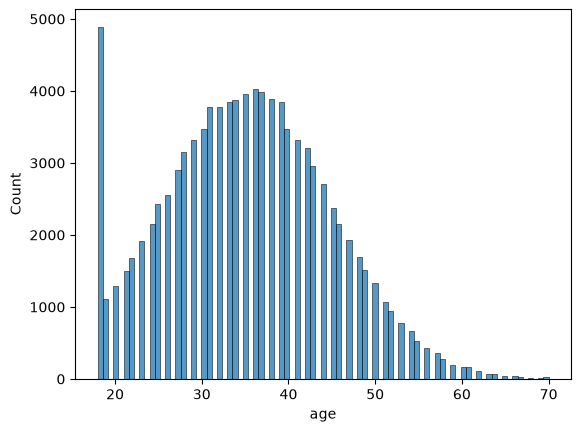

In [ ]:
sns.histplot(data=customers, x="age")

<Axes: xlabel='age'>

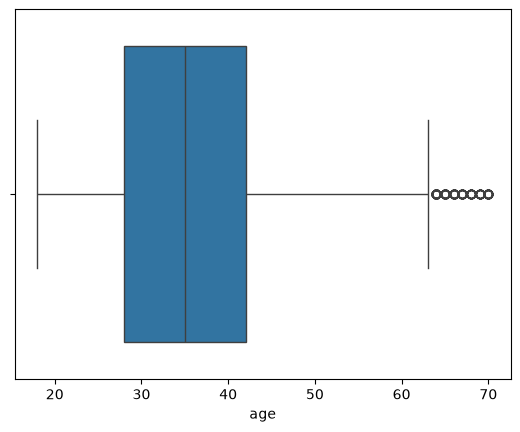

In [ ]:
sns.boxplot(data=customers, x="age")

In [5]:
customers["age"].mode()

0    18
Name: age, dtype: int64

In [8]:
mode_percentage = (customers["age"] == 18).mean() * 100
print(mode_percentage)

4.889


In [22]:
customers["age"].value_counts().sort_index().loc[18:35]

age
18    4889
19    1106
20    1295
21    1496
22    1673
23    1909
24    2146
25    2431
26    2548
27    2907
28    3153
29    3325
30    3477
31    3782
32    3781
33    3843
34    3878
35    3961
Name: count, dtype: int64

In [ ]:
customers[customers["age"] == 18].describe(include="all")

,customer_id,signup_date,country,age,gender,loyalty_tier,acquisition_channel
count,4889.000000,4889,4889,4889.0,4889,4889,4889
unique,NaN,1080,7,NaN,3,4,5
top,NaN,2023-01-17,US,NaN,Female,Bronze,Organic
freq,NaN,12,1706,NaN,2359,2937,1539
mean,49959.964001,NaN,NaN,18.0,NaN,NaN,NaN
std,28987.159102,NaN,NaN,0.0,NaN,NaN,NaN
min,16.000000,NaN,NaN,18.0,NaN,NaN,NaN
25%,25251.000000,NaN,NaN,18.0,NaN,NaN,NaN
50%,49923.000000,NaN,NaN,18.0,NaN,NaN,NaN
75%,75223.000000,NaN,NaN,18.0,NaN,NaN,NaN


In [16]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

In [17]:
age_18 = customers[customers["age"] == 18]
not_18 = customers[customers["age"] != 18]

In [18]:
age_18["signup_date"].dt.year.value_counts(normalize=True).sort_index() * 100

signup_date
2021    33.360605
2022    34.219677
2023    32.419718
Name: proportion, dtype: float64

In [19]:
not_18["signup_date"].dt.year.value_counts(normalize=True).sort_index() * 100

signup_date
2021    33.390460
2022    33.160202
2023    33.449338
Name: proportion, dtype: float64

In [ ]:
age_18["country"].value_counts(normalize=True) * 100

country
US    34.894661
IN    20.658621
UK    10.124770
CA    10.002045
BR     9.633872
DE     7.854367
AU     6.831663
Name: proportion, dtype: float64

In [ ]:
not_18["country"].value_counts(normalize=True) * 100

country
US    34.932868
IN    20.059720
UK    10.156554
BR    10.020923
CA     9.901063
DE     7.898140
AU     7.030733
Name: proportion, dtype: float64

In [ ]:
age_18["gender"].value_counts(normalize=True) * 100

gender
Female    48.251176
Male      47.535283
Other      4.213541
Name: proportion, dtype: float64

In [ ]:
not_18["gender"].value_counts(normalize=True) * 100

gender
Male      48.080664
Female    47.993397
Other      3.925939
Name: proportion, dtype: float64

In [ ]:
age_18["loyalty_tier"].value_counts(normalize=True) * 100

loyalty_tier
Bronze      60.073635
Silver      25.035795
Gold        11.474739
Platinum     3.415831
Name: proportion, dtype: float64

In [ ]:
not_18["loyalty_tier"].value_counts(normalize=True) * 100

loyalty_tier
Bronze      60.286402
Silver      24.905637
Gold        11.810411
Platinum     2.997550
Name: proportion, dtype: float64

In [ ]:
age_18["acquisition_channel"].value_counts(normalize=True) * 100

acquisition_channel
Organic        31.478830
Paid Search    29.351606
Social         14.706484
Email          14.481489
Referral        9.981591
Name: proportion, dtype: float64

In [ ]:
not_18["acquisition_channel"].value_counts(normalize=True) * 100

acquisition_channel
Organic        30.134264
Paid Search    29.980759
Social         14.993008
Email          14.924667
Referral        9.967301
Name: proportion, dtype: float64

In [20]:
age_18.duplicated(
    subset=["signup_date", "country", "gender", "loyalty_tier", "acquisition_channel"]
).sum()

np.int64(115)

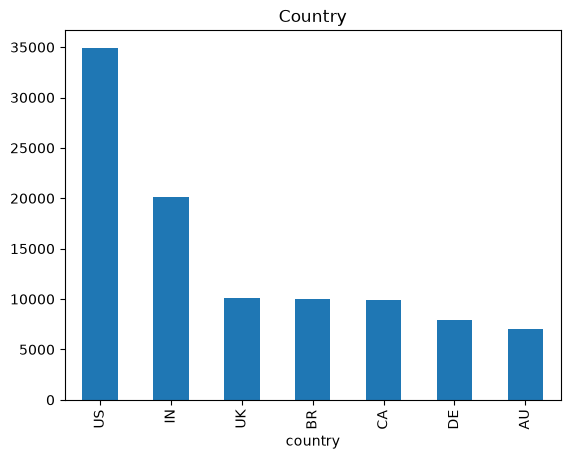

In [ ]:
customers["country"].value_counts().plot(kind="bar", title="Country")
plt.show()

In [4]:
customers["country"].value_counts(normalize=True) * 100

country
US    34.931
IN    20.089
UK    10.155
BR    10.002
CA     9.906
DE     7.896
AU     7.021
Name: proportion, dtype: float64

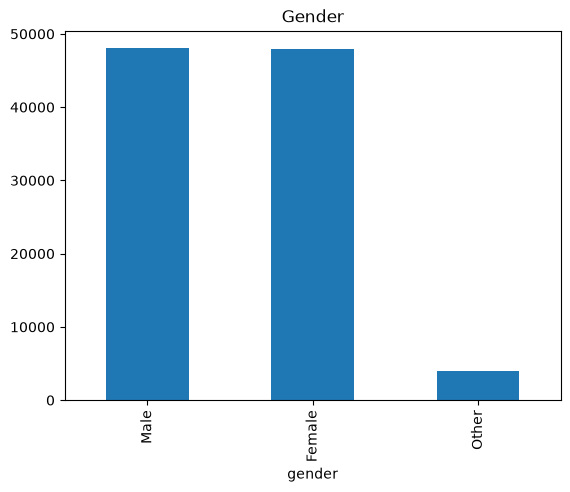

In [8]:
customers["gender"].value_counts().plot(kind="bar", title="Gender")
plt.show()

In [5]:
customers["gender"].value_counts(normalize=True) * 100

gender
Male      48.054
Female    48.006
Other      3.940
Name: proportion, dtype: float64

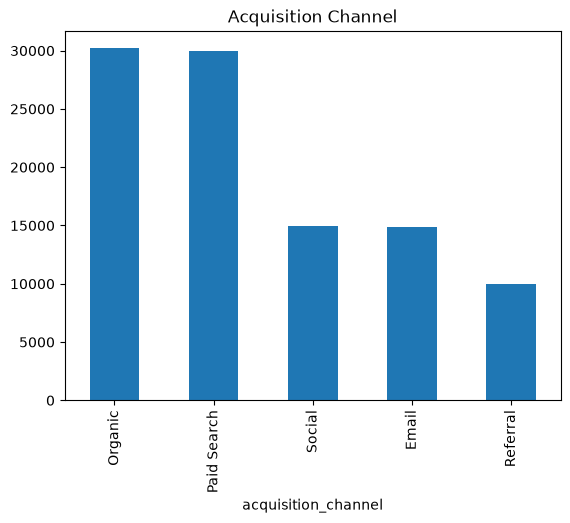

In [9]:
customers["acquisition_channel"].value_counts().plot(
    kind="bar", title="Acquisition Channel"
)
plt.show()

In [6]:
customers["acquisition_channel"].value_counts(normalize=True) * 100

acquisition_channel
Organic        30.200
Paid Search    29.950
Social         14.979
Email          14.903
Referral        9.968
Name: proportion, dtype: float64

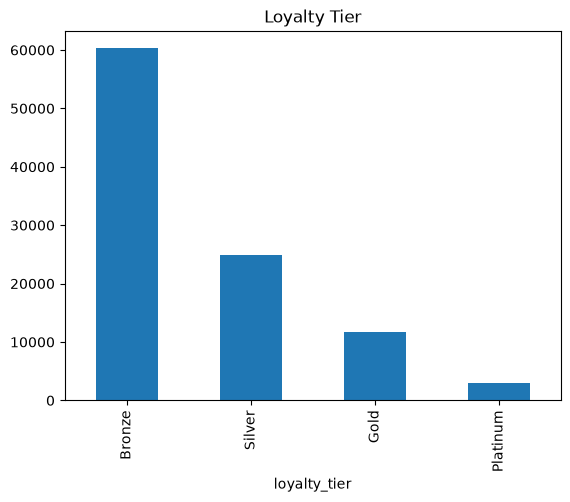

In [ ]:
customers["loyalty_tier"].value_counts().plot(kind="bar", title="Loyalty Tier")
plt.show()

In [7]:
customers["loyalty_tier"].value_counts(normalize=True) * 100

loyalty_tier
Bronze      60.276
Silver      24.912
Gold        11.794
Platinum     3.018
Name: proportion, dtype: float64

In [30]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

In [31]:
customers["signup_date"].min()

Timestamp('2021-01-01 00:00:00')

In [32]:
customers["signup_date"].max()

Timestamp('2023-12-31 00:00:00')

## Customers Table Overview

### Table Summary

The `customers` table contains demographic and acquisition information for **100,000 customers**. Each record represents a unique customer and includes attributes such as signup date, country, age, gender, loyalty tier, and acquisition channel. Each record represents a unique customer.

**Rows:** 100,000
**Columns:** 7
**Primary Key:** `customer_id`

### Column Summary

- `customer_id` : 100,000 unique customer IDs
- `signup_date` : 2021-01-01 - 2023-12-31
- `country` : US, IN, UK, BR, CA, DE, and AU
- `age` : 18-70
- `gender` : male, female, other
- `loyalty_tier` : Bronze, Silver, Gold, Platinum
- `acquisition_channel` : Referral, Organic, Paid Search, Social, Email

### Duplicate Rows
- The dataset contains 100,000 records and 100,000 unique `customer_id` values, confirming there are no duplicate primary keys.
- Excluding `customer_id`, there are 1,313 duplicate records based on the remaining customer attributes.
- Because the dataset does not contain unique identifiers (e.g., email address), it cannot be determined whether these represent duplicate customer profiles or distinct customers with identical demographic characteristics.

### Data Types
- `signup_date` is stored as a string (`object`) rather than a datetime.
- This column will be converted to a datetime type during the data cleaning stage to enable time-based analysis.
- All remaining columns have appropriate data types for their contents.

### Missing Values
- No missing values were identified in the customer dataset.

### Country
- The United States is the largest customer market, accounting for approximately 35% of all customers.
- The remaining customers are distributed across six additional countries

### Gender
- The gender distribution is balanced, with approximately 48% male, 48% female, and 4% other.
 
### Acquisition Channel
- Organic Search and Paid Search each account for approximately 30% of customer acquisitions, making them the two most common acquisition channels.

### Loyalty Tier
- Approximately 60% of customers belong to the Bronze loyalty tier, making it the largest customer segment by loyalty status

### Age
- Customer ages are approximately normally distributed with a median age of 35.
- A pronounced spike occurs at age 18 (4,889 customers versus 1,106 at age 19).
- Comparisons across signup date, country, gender, loyalty tier, acquisition channel, and duplicate records revealed no evidence of a data quality issue.
- The values are retained and the age-18 segment will be revisited during cross-table analysis to determine whether it exhibits different marketing behaviour.

## Summary
The `customers` table is complete and well structured, with no missing values or duplicate primary keys. Aside from converting `signup_date` to a datetime, no significant data quality issues were identified. The primary anomaly is the overrepresentation of customers aged 18, which will be investigated further during cross-table analysis.

## Products Table

In [20]:
products.head()

,product_id,category,brand,base_price,launch_date,is_premium
0,1,Grocery,Brand_58,14.19,2021-08-02,0
1,2,Fashion,Brand_1,25.80,2021-09-14,0
2,3,Electronics,Brand_70,165.46,2021-01-18,1
3,4,Fashion,Brand_56,75.45,2023-03-03,1
4,5,Sports,Brand_1,72.50,2022-04-19,1


In [21]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   product_id   2000 non-null   int64  
 1   category     2000 non-null   str    
 2   brand        2000 non-null   str    
 3   base_price   2000 non-null   float64
 4   launch_date  2000 non-null   str    
 5   is_premium   2000 non-null   int64  
dtypes: float64(1), int64(2), str(3)
memory usage: 93.9 KB


In [ ]:
products.describe(include="all")

,product_id,category,brand,base_price,launch_date,is_premium
count,2000.000000,2000,2000,2000.000000,2000,2000.000000
unique,NaN,6,100,NaN,901,NaN
top,NaN,Electronics,Brand_7,NaN,2021-01-18,NaN
freq,NaN,455,32,NaN,7,NaN
mean,1000.500000,NaN,NaN,72.166650,NaN,0.500000
std,577.494589,NaN,NaN,52.315792,NaN,0.500125
min,1.000000,NaN,NaN,5.110000,NaN,0.000000
25%,500.750000,NaN,NaN,32.505000,NaN,0.000000
50%,1000.500000,NaN,NaN,61.245000,NaN,0.500000
75%,1500.250000,NaN,NaN,97.955000,NaN,1.000000


In [26]:
products.nunique()

product_id     2000
category          6
brand           100
base_price     1869
launch_date     901
is_premium        2
dtype: int64

In [33]:
products.columns.tolist()

['product_id', 'category', 'brand', 'base_price', 'launch_date', 'is_premium']

In [35]:
products.duplicated(
    subset=["category", "brand", "base_price", "launch_date", "is_premium"]
).sum()

np.int64(0)

In [36]:
products["launch_date"] = pd.to_datetime(products["launch_date"])

In [37]:
products["launch_date"].min()

Timestamp('2021-01-01 00:00:00')

In [38]:
products["launch_date"].max()

Timestamp('2023-12-31 00:00:00')

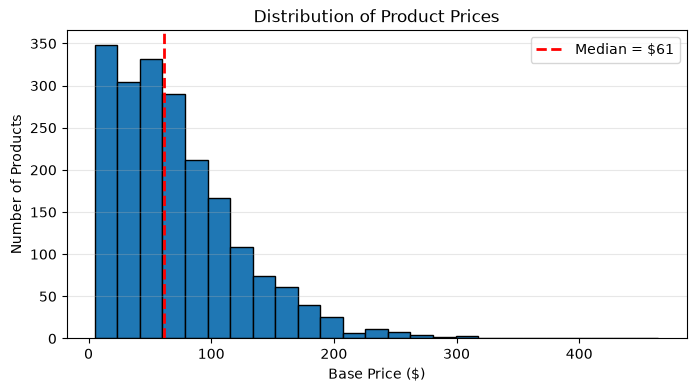

In [ ]:
median = products["base_price"].median()

plt.figure(figsize=(8, 4))

plt.hist(products["base_price"], bins=25, edgecolor="black")

plt.axvline(
    median,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = ${median:.0f}",
)

plt.title("Distribution of Product Prices")
plt.xlabel("Base Price ($)")
plt.ylabel("Number of Products")

plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.show()

<Axes: xlabel='base_price'>

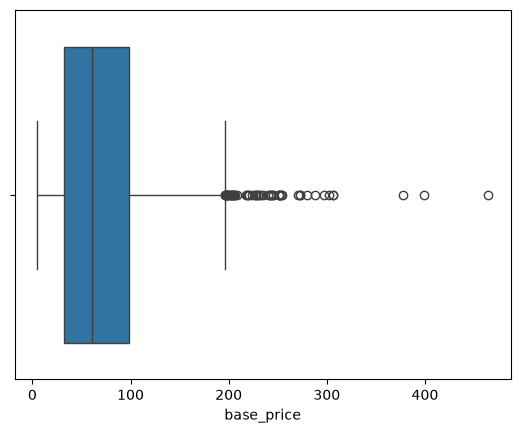

In [ ]:
sns.boxplot(data=products, x="base_price")

In [5]:
products.sort_values("base_price", ascending=False).head(50)

,product_id,category,brand,base_price,launch_date,is_premium
495,496,Electronics,Brand_16,464.58,2022-10-31,1
222,223,Electronics,Brand_6,399.36,2023-02-22,1
729,730,Electronics,Brand_56,377.64,2023-09-28,1
1184,1185,Electronics,Brand_80,306.19,2021-04-14,1
1791,1792,Electronics,Brand_80,305.81,2021-06-02,1
1589,1590,Home,Brand_70,301.83,2023-01-01,1
59,60,Electronics,Brand_84,297.63,2021-06-26,1
315,316,Electronics,Brand_57,288.45,2021-05-03,1
704,705,Electronics,Brand_53,279.87,2021-02-14,1
627,628,Electronics,Brand_67,272.98,2021-05-26,1


In [40]:
products.groupby("category")["base_price"].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Beauty,201.0,32.586418,13.911143,8.90,23.3900,30.090,39.1100,88.05
Electronics,455.0,130.447626,55.199686,33.53,93.5000,118.830,157.6500,464.58
Fashion,418.0,53.483182,22.979997,12.79,37.4250,50.820,63.5875,170.42
Grocery,312.0,16.195833,6.843622,5.11,11.5700,15.085,19.6900,46.89
Home,396.0,86.837601,38.176987,25.15,60.0825,78.840,106.6025,301.83
Sports,218.0,76.298165,27.655825,22.57,55.7425,74.140,91.6475,174.13


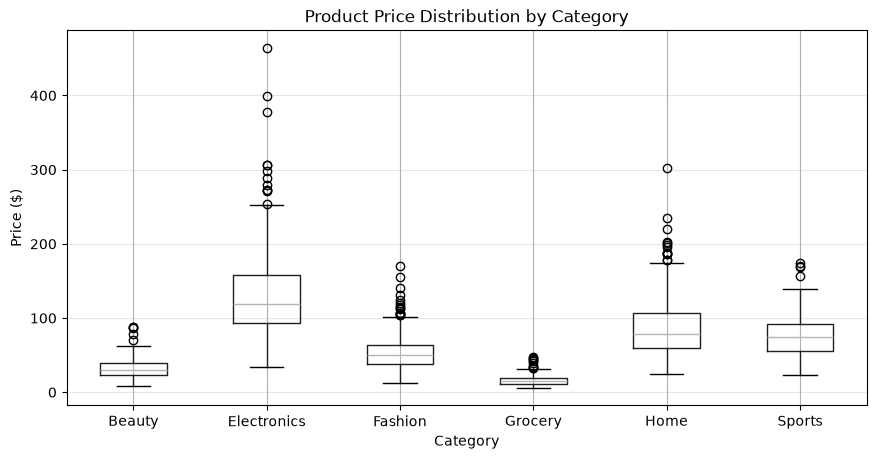

In [ ]:
products.boxplot(column="base_price", by="category", figsize=(10, 5))

plt.title("Product Price Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Price ($)")
plt.grid(axis="y", alpha=0.3)

plt.show()

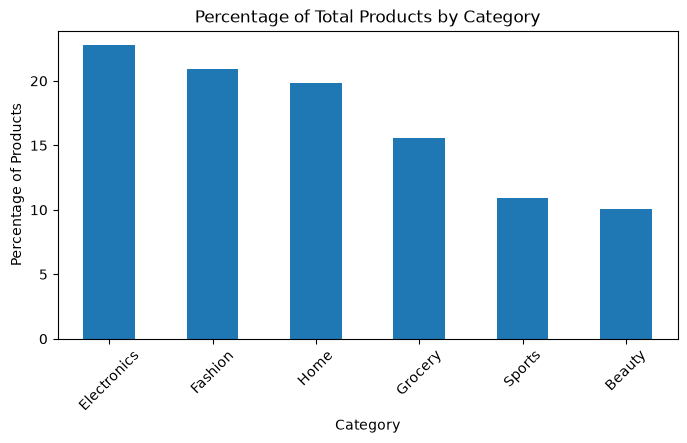

In [11]:
(
    products["category"]
    .value_counts(normalize=True)
    .mul(100)
    .plot(kind="bar", figsize=(8, 4))
)

plt.title("Percentage of Total Products by Category")
plt.xlabel("Category")
plt.ylabel("Percentage of Products")
plt.xticks(rotation=45)
plt.show()

In [28]:
products["category"].value_counts(normalize=True).mul(100).round(1)

category
Electronics    22.8
Fashion        20.9
Home           19.8
Grocery        15.6
Sports         10.9
Beauty         10.0
Name: proportion, dtype: float64

In [ ]:
premium_pct = (
    pd.crosstab(products["category"], products["is_premium"], normalize="index") * 100
).round(1)

premium_pct

is_premium,0,1
category,,
Beauty,96.5,3.5
Electronics,4.6,95.4
Fashion,70.6,29.4
Grocery,100.0,0.0
Home,26.3,73.7
Sports,33.9,66.1


In [ ]:
products.groupby("is_premium")["base_price"].agg(
    Mean="mean", Median="median", Min="min", Max="max"
).round(2)

,Mean,Median,Min,Max
is_premium,,,,
0,33.20,32.49,5.11,61.24
1,111.13,97.96,61.25,464.58


In [ ]:
products.groupby(["category", "is_premium"])["base_price"].agg(
    Mean="mean", Median="median", Count="count"
).round(2)

Mean  Median  Count
category    is_premium                       
Beauty      0            31.01   29.58    194
            1            76.35   78.79      7
Electronics 0            53.81   56.53     21
            1           134.16  121.20    434
Fashion     0            41.97   42.69    295
            1            81.09   76.17    123
Grocery     0            16.20   15.08    312
Home        0            48.30   49.49    104
            1           100.56   89.95    292
Sports      0            48.58   50.42     74
            1            90.54   84.66    144

## Products Table Overview

### Table Summary

The products table contains information on 2,000 products, including product category, brand, price, launch date, and premium status. Each record represents a unique product.

**Rows:** 2000
**Columns:** 6
**Primary Key:** `product_id`

### Columns Summary

- `product_id` : 2000 unique product IDs
- `category` : Electronics, Fashion, Home, Grocery, Sport, Beauty
- `brand` : 100 unique brands
- `base_price` : $5.11 - $464.58
- `launch_date` : 2021-01-01 to 2023-12-31
- `is_premium` : Boolean flag indicating whether a product is classified as premium

### Duplicate Rows
- The dataset contains **2000 products** and **2000 unique `product_id` values**, confirming there are no duplicate primary keys.
- Excluding `product_id`, no duplicate records were identified 

### Data Types
- `launch_date` is stored as a string (`object`) rather than a datetime.
- This column will be converted to a datetime type during the data cleaning
- All remaining columns have appropriate data types for their contents.

### Missing Values
- No missing values were identified in the products dataset

### Price Distribution
- Product prices range from approximately **$5** to **$464**, with a median price of **$61** and an average price of **$71**.
- The price distribution is **right-skewed**, with most products priced below **$100**.
- A small number of high-priced products create a long upper tail, causing the mean to exceed the median

### Pricing by Product Categoryt
- Products priced above **$300** are almost exclusively found in the **Electronics** category with the exception of one **Home** product
- **Electronics** account for approximately **23%** of the product catalog and have the highest average price(**$130**). While most electronics are priced near the category average, a small number of high-priced products (up to $465) increase the average above the median ($119), indicating a right-skewed distribution.
- Elecontrics also exhibit the **widest price range** of any product category
- In contrast, Groceries, Beauty, and Fashion account for approximately 47% of all products and have average prices below the overall median price
- The observed price variation appears to reflect genuine differences in product categories rather than data quality issues; therefore, all products will be retained for further analysis.

### Premium Products
- **Electronics** and **Home** contain the highest proportion of premium products, with approximately 95% and 74% of products classified as premium, respectively.
- Across all categories, premium products have an average price of approximately **$111**, compared with **$33** for non-premium products.
- The strong relationship between premium status and price suggests that the is_premium flag is a meaningful indicator of product positioning within the dataset.
- The concentration of premium products within the Electronics category helps explain why Electronics have the highest average prices and contribute disproportionately to the right-skewed overall price distribution

### Summary
The `products` table is complete and free of significant data quality issues. Product prices are right-skewed, driven primarily by the Electronics category, which contains the highest proportion of premium and high-priced products. These characteristics appear to reflect genuine business differences rather than anomalies, making the table suitable for further analysis


Events Table

In [31]:
events.head()

,event_id,timestamp,customer_id,session_id,event_type,product_id,device_type,traffic_source,campaign_id,page_category,session_duration_sec,experiment_group
0,1,2021-01-14 13:35:43,43812,535101,view,1004.0,desktop,Email,43,PLP,115.1,Control
1,2,2021-12-03 21:36:50,71340,96426,add_to_cart,986.0,desktop,Email,10,PDP,32.4,Variant_A
2,3,2021-12-27 08:25:15,59540,220126,purchase,1630.0,mobile,Organic,0,PDP,190.7,Variant_A
3,4,2022-01-22 15:06:54,3601,484555,add_to_cart,1532.0,desktop,Paid Search,30,Checkout,134.8,Variant_B
4,5,2021-05-10 12:03:09,92735,60646,bounce,NaN,desktop,Email,26,PLP,53.1,Variant_A


In [32]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   event_id              int64  
 1   timestamp             str    
 2   customer_id           int64  
 3   session_id            int64  
 4   event_type            str    
 5   product_id            float64
 6   device_type           str    
 7   traffic_source        str    
 8   campaign_id           int64  
 9   page_category         str    
 10  session_duration_sec  float64
 11  experiment_group      str    
dtypes: float64(2), int64(4), str(6)
memory usage: 183.1 MB


In [5]:
events.describe(include="all")

,event_id,timestamp,customer_id,session_id,event_type,product_id,device_type,traffic_source,campaign_id,page_category,session_duration_sec,experiment_group
count,2.000000e+06,2000000,2.000000e+06,2.000000e+06,2000000,1.799629e+06,1959700,2000000,2.000000e+06,2000000,2.000000e+06,2000000
unique,NaN,1977065,NaN,NaN,5,NaN,3,10,NaN,5,NaN,3
top,NaN,2023-09-18 07:00:22,NaN,NaN,view,NaN,mobile,Organic,NaN,PLP,NaN,Control
freq,NaN,4,NaN,NaN,1043573,NaN,1176146,776758,NaN,601284,NaN,1198404
mean,1.000000e+06,NaN,5.001209e+04,3.330514e+05,NaN,1.000100e+03,NaN,NaN,1.276203e+01,NaN,1.306426e+02,NaN
std,5.773504e+05,NaN,2.887960e+04,1.924715e+05,NaN,5.776716e+02,NaN,NaN,1.634052e+01,NaN,1.590376e+02,NaN
min,1.000000e+00,NaN,1.000000e+00,1.000000e+00,NaN,1.000000e+00,NaN,NaN,0.000000e+00,NaN,1.000000e-01,NaN
25%,5.000008e+05,NaN,2.501000e+04,1.662308e+05,NaN,5.000000e+02,NaN,NaN,0.000000e+00,NaN,5.810000e+01,NaN
50%,1.000000e+06,NaN,5.000900e+04,3.328190e+05,NaN,1.000000e+03,NaN,NaN,0.000000e+00,NaN,1.017000e+02,NaN
75%,1.500000e+06,NaN,7.503800e+04,4.997712e+05,NaN,1.501000e+03,NaN,NaN,2.600000e+01,NaN,1.640000e+02,NaN


In [34]:
events.isna().sum().sort_values(ascending=False)

product_id              200371
device_type              40300
event_id                     0
timestamp                    0
session_id                   0
customer_id                  0
event_type                   0
traffic_source               0
campaign_id                  0
page_category                0
session_duration_sec         0
experiment_group             0
dtype: int64

In [ ]:
missing_values = events.isna().mean() * 100
missing_values.sort_values(ascending=False)

product_id              10.01855
device_type              2.01500
event_id                 0.00000
timestamp                0.00000
session_id               0.00000
customer_id              0.00000
event_type               0.00000
traffic_source           0.00000
campaign_id              0.00000
page_category            0.00000
session_duration_sec     0.00000
experiment_group         0.00000
dtype: float64

In [36]:
events.duplicated().sum()

np.int64(0)

In [13]:
events.columns.tolist()

['event_id',
 'timestamp',
 'customer_id',
 'session_id',
 'event_type',
 'product_id',
 'device_type',
 'traffic_source',
 'campaign_id',
 'page_category',
 'session_duration_sec',
 'experiment_group']

In [ ]:
events.duplicated(
    subset=[
        "timestamp",
        "customer_id",
        "session_id",
        "event_type",
        "product_id",
        "device_type",
        "traffic_source",
        "campaign_id",
        "page_category",
        "session_duration_sec",
        "experiment_group",
    ]
).sum()

np.int64(0)

In [37]:
events.nunique()

event_id                2000000
timestamp               1977065
customer_id              100000
session_id               633462
event_type                    5
product_id                 2000
device_type                   3
traffic_source               10
campaign_id                  51
page_category                 5
session_duration_sec      16524
experiment_group              3
dtype: int64

In [15]:
events["customer_id"].isin(customers["customer_id"]).all()

np.True_

In [16]:
events["product_id"].dropna().isin(products["product_id"]).all()

np.True_

In [17]:
events["campaign_id"].dropna().isin(campaigns["campaign_id"]).all()

np.False_

In [18]:
set(events["campaign_id"].dropna()) - set(campaigns["campaign_id"])

{0}

In [ ]:
events.loc[
    ~events["campaign_id"].isin(campaigns["campaign_id"]), "campaign_id"
].unique()

array([0])

In [21]:
events["campaign_id"].value_counts().loc[0]

np.int64(1000251)

In [ ]:
events.loc[~events["campaign_id"].isin(campaigns["campaign_id"])].head(20)

,event_id,timestamp,customer_id,session_id,event_type,product_id,device_type,traffic_source,campaign_id,page_category,session_duration_sec,experiment_group
2,3,2021-12-27 08:25:15,59540,220126,purchase,1630.0,mobile,Organic,0,PDP,190.7,Variant_A
5,6,2022-03-04 11:41:45,3184,221551,click,628.0,desktop,Organic,0,PDP,36.8,Variant_A
6,7,2021-01-27 10:17:26,89606,569910,click,369.0,desktop,Organic,0,PDP,58.2,Variant_B
9,10,2023-05-30 05:56:14,55257,240165,add_to_cart,755.0,mobile,Direct,0,PLP,73.3,Control
10,11,2021-09-06 21:26:22,94678,294260,add_to_cart,1141.0,mobile,Organic,0,Home,12.8,Variant_B
14,15,2022-09-10 07:05:51,8024,292502,bounce,NaN,desktop,Organic,0,Checkout,33.0,Variant_B
15,16,2023-07-16 20:33:23,30501,36337,view,1337.0,mobile,Direct,0,Cart,297.9,Control
16,17,2021-04-14 13:12:42,47785,438870,add_to_cart,748.0,mobile,Organic,0,Checkout,52.4,Control
18,19,2021-10-04 19:02:42,81842,249671,view,618.0,desktop,Organic,0,Cart,227.7,Control
19,20,2023-11-30 19:08:16,69864,54913,view,1822.0,desktop,Direct,0,PLP,177.6,Control


In [ ]:
pd.crosstab(events["campaign_id"], events["traffic_source"])

traffic_source,DIRECT,Direct,EMAIL,Email,ORGANIC,Organic,PAID SEARCH,Paid Search,SOCIAL,Social
campaign_id,,,,,,,,,,
0,5892,193870,0,0,23731,776758,0,0,0,0
1,0,0,167,5765,0,0,232,7639,160,5922
2,0,0,168,5849,0,0,247,7775,173,5798
3,0,0,175,5730,0,0,230,7713,190,5839
4,0,0,174,5766,0,0,231,7787,188,5774
5,0,0,181,5812,0,0,228,7717,175,5696
6,0,0,203,5761,0,0,231,7741,173,5840
7,0,0,195,5685,0,0,239,7648,181,5930
8,0,0,189,5643,0,0,237,7698,192,5769


In [ ]:
pd.crosstab(
    events["traffic_source"], events["campaign_id"] == 0, normalize="index"
).round(3) * 100

campaign_id,False,True
traffic_source,,
DIRECT,0.0,100.0
Direct,0.0,100.0
EMAIL,100.0,0.0
Email,100.0,0.0
ORGANIC,0.0,100.0
Organic,0.0,100.0
PAID SEARCH,100.0,0.0
Paid Search,100.0,0.0
SOCIAL,100.0,0.0


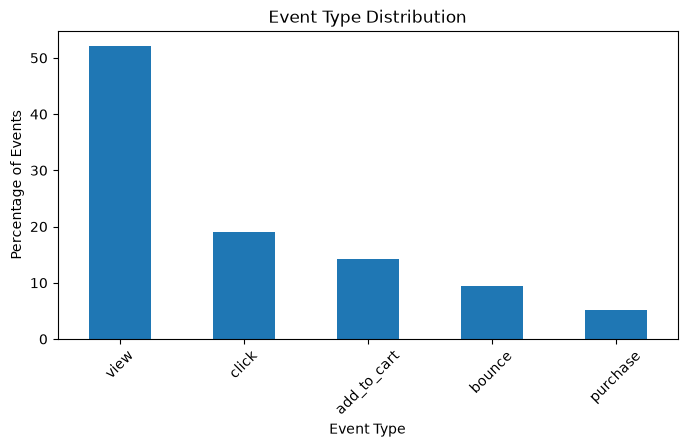

In [ ]:
(
    events["event_type"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
    .plot(kind="bar", figsize=(8, 4))
)

plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Percentage of Events")
plt.xticks(rotation=45)
plt.show()

In [29]:
events["event_type"].value_counts(normalize=True).mul(100).round(1)

event_type
view           52.2
click          19.0
add_to_cart    14.2
bounce          9.5
purchase        5.2
Name: proportion, dtype: float64

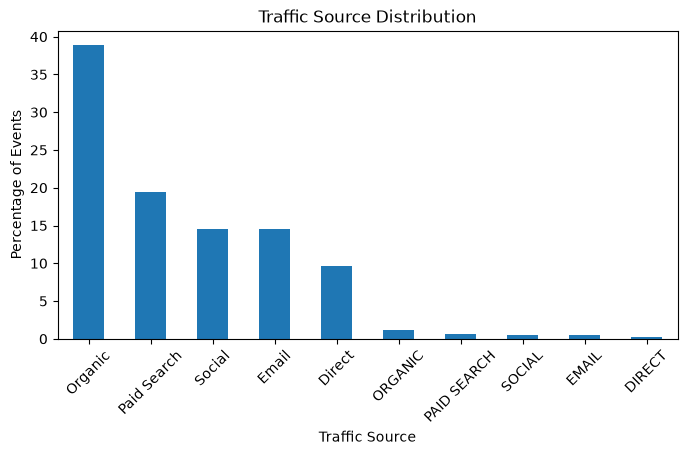

In [ ]:
(
    events["traffic_source"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
    .plot(kind="bar", figsize=(8, 4))
)

plt.title("Traffic Source Distribution")
plt.xlabel("Traffic Source")
plt.ylabel("Percentage of Events")
plt.xticks(rotation=45)
plt.show()

In [33]:
events["traffic_source"].value_counts(normalize=True).mul(100).round(1)

traffic_source
Organic        38.8
Paid Search    19.4
Social         14.6
Email          14.5
Direct          9.7
ORGANIC         1.2
PAID SEARCH     0.6
SOCIAL          0.5
EMAIL           0.4
DIRECT          0.3
Name: proportion, dtype: float64

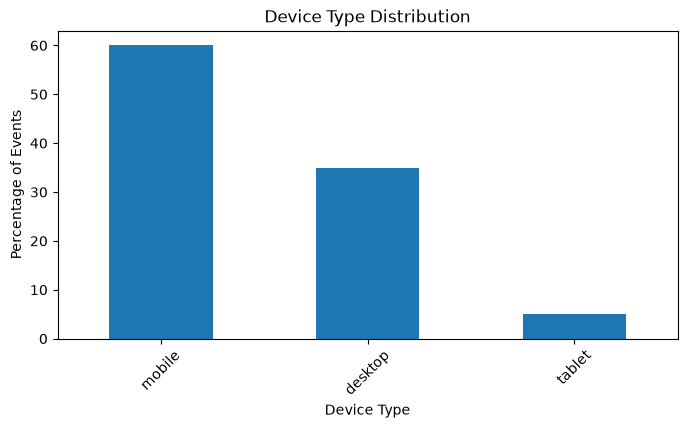

In [ ]:
(
    events["device_type"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
    .plot(kind="bar", figsize=(8, 4))
)

plt.title("Device Type Distribution")
plt.xlabel("Device Type")
plt.ylabel("Percentage of Events")
plt.xticks(rotation=45)
plt.show()

In [36]:
events["device_type"].value_counts(normalize=True).mul(100).round(1)

device_type
mobile     60.0
desktop    35.0
tablet      5.0
Name: proportion, dtype: float64

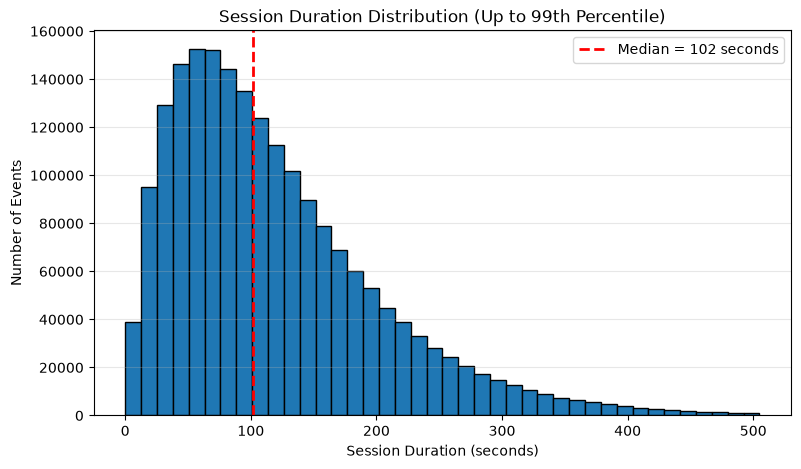

In [ ]:
median = events["session_duration_sec"].median()
p99 = events["session_duration_sec"].quantile(0.99)

plt.figure(figsize=(9, 5))

plt.hist(
    events.loc[events["session_duration_sec"] <= p99, "session_duration_sec"],
    bins=40,
    edgecolor="black",
)

plt.axvline(
    median,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median:.0f} seconds",
)

plt.title("Session Duration Distribution (Up to 99th Percentile)")
plt.xlabel("Session Duration (seconds)")
plt.ylabel("Number of Events")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.show()

In [39]:
p99

np.float64(504.9)

In [42]:
events["session_duration_sec"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
).round(1)

count    2000000.0
mean         130.6
std          159.0
min            0.1
25%           58.1
50%          101.7
75%          164.0
90%          240.0
95%          298.3
99%          504.9
max         7533.8
Name: session_duration_sec, dtype: float64

In [ ]:
duration_counts = events.groupby("session_id")["session_duration_sec"].nunique()

duration_counts.value_counts()

session_duration_sec
2     149626
3     149393
4     111717
1      99604
5      67196
6      33757
7      14406
8       5297
9       1750
10       541
11       126
12        37
13        11
14         1
Name: count, dtype: int64

In [ ]:
sample_session = events["session_id"].value_counts().idxmax()

events.loc[
    events["session_id"] == sample_session,
    ["session_id", "customer_id", "timestamp", "event_type", "session_duration_sec"],
].sort_values("timestamp").reset_index(drop=True)

,session_id,customer_id,timestamp,event_type,session_duration_sec
0,627038,49001,2021-01-14 10:12:19,view,23.3
1,627038,50385,2021-01-30 22:38:13,view,5.7
2,627038,91121,2021-03-15 18:24:33,view,59.2
3,627038,9266,2021-04-04 19:45:49,view,82.2
4,627038,15869,2021-05-30 18:12:03,bounce,190.0
5,627038,37779,2021-08-28 18:04:27,view,101.8
6,627038,57014,2021-09-13 13:21:26,view,50.7
7,627038,40069,2021-10-12 21:48:24,view,47.5
8,627038,2362,2022-08-21 13:39:32,view,36.0
9,627038,70308,2022-11-23 15:08:36,view,57.3


In [ ]:
random_session = events["session_id"].sample(1, random_state=42).iloc[0]

events.loc[
    events["session_id"] == random_session,
    ["session_id", "customer_id", "timestamp", "event_type", "session_duration_sec"],
].sort_values("timestamp").reset_index(drop=True)

,session_id,customer_id,timestamp,event_type,session_duration_sec
0,567862,9472,2021-01-11 06:53:34,view,216.5
1,567862,77043,2021-03-13 19:21:06,view,114.6
2,567862,17868,2022-01-07 15:02:52,view,43.5
3,567862,73507,2022-07-19 08:13:20,click,68.1
4,567862,71707,2023-02-14 07:02:05,click,195.8
5,567862,97740,2023-09-12 05:23:00,purchase,77.5
6,567862,11740,2023-10-27 15:48:57,view,20.0
7,567862,99470,2023-12-03 16:22:20,view,128.7


In [ ]:
session_customer_counts = events.groupby("session_id")["customer_id"].nunique()

session_customer_counts.describe()

count    633462.000000
mean          3.157192
std           1.630868
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          14.000000
Name: customer_id, dtype: float64

In [54]:
(session_customer_counts > 1).sum()

np.int64(533914)

In [ ]:
((session_customer_counts > 1).mean() * 100).round(2)

np.float64(84.29)

In [48]:
random_session = events["session_id"].sample(1, random_state=42).iloc[0]
random_session

np.int64(567862)

In [ ]:
events.loc[events["session_id"] == sample_session, "customer_id"].nunique()

14

In [4]:
events_campaigns = events.merge(
    campaigns[["campaign_id", "start_date", "end_date"]], on="campaign_id", how="left"
)

In [6]:
events_campaigns = events_campaigns[events_campaigns["campaign_id"] != 0]

In [15]:
date_cols = ["timestamp", "start_date", "end_date"]

events_campaigns[date_cols] = events_campaigns[date_cols].apply(pd.to_datetime)

events["timestamp"] = pd.to_datetime(events["timestamp"])

In [8]:
before_start = events_campaigns[
    events_campaigns["timestamp"] < events_campaigns["start_date"]
]

len(before_start)

501187

In [9]:
after_end = events_campaigns[
    events_campaigns["timestamp"] > events_campaigns["end_date"]
]

len(after_end)

451952

In [10]:
invalid_events = before_start.shape[0] + after_end.shape[0]

pct_invalid = invalid_events / len(events_campaigns) * 100

print(f"{pct_invalid:.2f}%")

95.34%


In [ ]:
campaign_events = events_campaigns[events_campaigns["campaign_id"] != 0]

before_pct = len(before_start) / len(campaign_events) * 100
after_pct = len(after_end) / len(campaign_events) * 100
within_pct = (
    (campaign_events["timestamp"] >= campaign_events["start_date"])
    & (campaign_events["timestamp"] <= campaign_events["end_date"])
).mean() * 100

print(f"Before campaign: {before_pct:.2f}%")
print(f"During campaign: {within_pct:.2f}%")
print(f"After campaign: {after_pct:.2f}%")

Before campaign: 50.13%
During campaign: 4.66%
After campaign: 45.21%


In [ ]:
campaign_events = events_campaigns[events_campaigns["campaign_id"] != 0].copy()

before_mask = campaign_events["timestamp"] < campaign_events["start_date"]

during_mask = (campaign_events["timestamp"] >= campaign_events["start_date"]) & (
    campaign_events["timestamp"] <= campaign_events["end_date"]
)

after_mask = campaign_events["timestamp"] > campaign_events["end_date"]

before_pct = before_mask.mean() * 100
during_pct = during_mask.mean() * 100
after_pct = after_mask.mean() * 100
invalid_pct = (before_mask | after_mask).mean() * 100

print(f"Before campaign: {before_pct:.2f}%")
print(f"During campaign: {during_pct:.2f}%")
print(f"After campaign: {after_pct:.2f}%")
print(f"Outside campaign period: {invalid_pct:.2f}%")

Before campaign: 50.13%
During campaign: 4.66%
After campaign: 45.21%
Outside campaign period: 95.34%


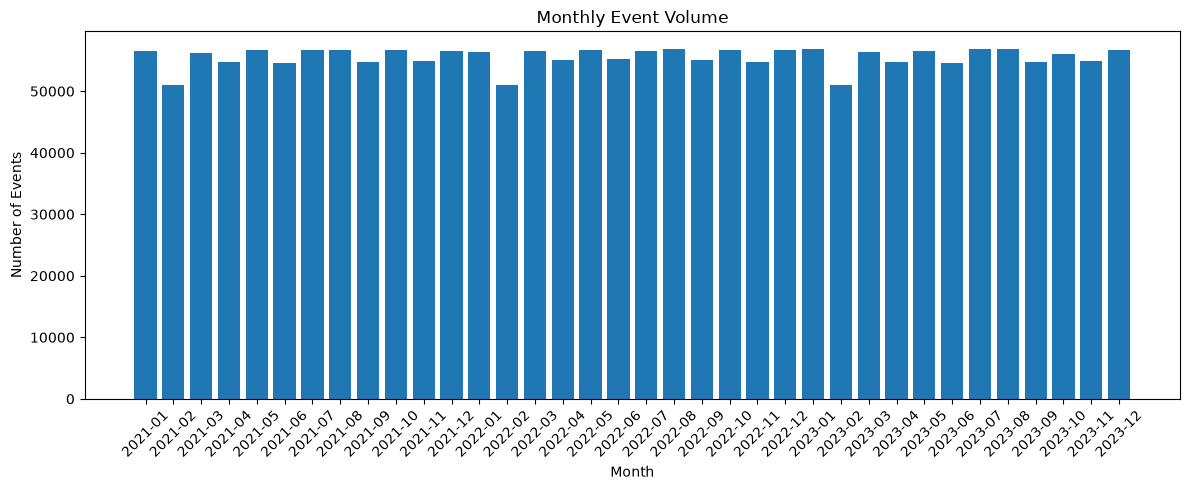

In [ ]:
events["event_month"] = events["timestamp"].dt.to_period("M")

monthly_events = events.groupby("event_month").size().reset_index(name="event_count")

monthly_events["event_month"] = monthly_events["event_month"].astype(str)


plt.figure(figsize=(12, 5))
plt.bar(monthly_events["event_month"], monthly_events["event_count"])

plt.xticks(rotation=45)
plt.title("Monthly Event Volume")
plt.xlabel("Month")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()

In [ ]:
customer = events["customer_id"].value_counts().idxmax()

events.loc[
    events["customer_id"] == customer, ["timestamp", "campaign_id", "traffic_source"]
].sort_values("timestamp")

,timestamp,campaign_id,traffic_source
62499,2021-01-09 04:10:41,0,Direct
495788,2021-01-17 14:11:24,32,Paid Search
1547019,2021-03-02 22:58:23,0,Direct
551324,2021-03-09 05:24:13,20,Email
1341137,2021-03-29 03:57:08,0,Direct
821406,2021-03-29 12:45:05,0,Organic
630796,2021-04-13 12:10:30,43,Social
750916,2021-06-16 15:13:18,43,Social
1033514,2021-06-18 12:44:49,0,Direct
1908434,2021-09-09 22:27:43,0,DIRECT


In [ ]:
events.loc[events["campaign_id"] == 5, "timestamp"].agg(["min", "max"])

min    2021-01-01 03:12:46
max    2023-12-31 21:40:23
Name: timestamp, dtype: str

In [ ]:
campaigns.loc[campaigns["campaign_id"] == 5, ["start_date", "end_date"]]

,start_date,end_date
4,2022-07-09,2022-09-29


In [ ]:
# Specify target columns
columns_to_check = [
    "event_type",
    "device_type",
    "traffic_source",
    "page_category",
    "experiment_group",
]

# Get a dictionary of unique arrays
unique_dict = {col: events[col].unique().tolist() for col in columns_to_check}

print(unique_dict)

{'event_type': ['view', 'add_to_cart', 'purchase', 'bounce', 'click'], 'device_type': ['desktop', 'mobile', 'tablet', nan], 'traffic_source': ['Email', 'Organic', 'Paid Search', 'Social', 'Direct', 'PAID SEARCH', 'DIRECT', 'EMAIL', 'ORGANIC', 'SOCIAL'], 'page_category': ['PLP', 'PDP', 'Checkout', 'Home', 'Cart'], 'experiment_group': ['Control', 'Variant_A', 'Variant_B']}


In [9]:
events["timestamp"].max()

'2023-12-31 23:57:50'

In [10]:
events["timestamp"].min()

'2021-01-01 00:01:28'

## Events Table Overview

### Table Summary

The `events` table contains **2,000,000 customer interaction events** recorded between January 1, 2021, and December 31, 2023. Each row represents an individual customer event and may be linked to a customer, product, and marketing campaign.

The table contains **100,000 unique customers** and **633,462 unique session IDs**. However, further investigation found that the session identifiers are not reliable indicators of individual browsing sessions.

**Rows:** 2,000,000
**Columns:** 12
**Primary Key:** `event_id`
**Foreign Keys**: `customer_id`, `product_id`, `campaign_id`

### Columns Summary

- `event_id` : 2,000,000 unique event records
- `timestamp` : 2021-01-01 to 2023-12-31           
- `customer_id` : Foreign key to the `customers` table
- `session_id` : Intended session identifier; later analysis found that values are reused across customers
- `event_type` : View, Cick, Add to Cart, Bounce, Purchase
- `product_id` : Foreign key to the `products` table
- `device_type` : Desktop, Mobile, Tablet
- `traffic_source` : Email, Organic, Paid Search, Social, Direct
- `campaign_id` : Campaign identifier, including 0 for events without campaign attribution
- `page_category` : PLP, PDP, Checkout, Home, Cart
- `session_duration_sec` : 0.1 - 7,533.8          
- `experiment_group` : Control, Variant_A, Variant_B


### Missing Values
- Missing values are concentrated in two columns.
- `product_id` contains **200,371** missing values (**10%** of records). This may reflect events that are not directly associated with a specific product (for example, homepage visits or general navigation).
- `device_type` contains **40,300** missing values (**2%** of records). These may represent events where device information was unavailable or not captured.
- No other columns contain substantial levels of missing data.
- The missing values appear plausible given the nature of event tracking and will be retained unless further analysis indicates they require treatment.

### Duplicates
- All **2,000,000** event records have unique event_id values.
- No duplicate event records were identified.

### Inconsistent Values
- `traffic_source` contains inconsistent capitalization (for example, "Email" and "EMAIL"), resulting in ten unique values instead of the expected five. 
- These values will be standardized during data cleaning.

### Data Types
- `timestamp` is currently stored as a string (object) and will be converted to a datetime during data cleaning.
- All remaining columns have appropriate data types.

### Foreign Key Validation
- Foreign key validation confirmed that all `customer_id` and non-null `product_id` values exist in their corresponding dimension tables.
- A referential integrity check identified that `campaign_id = 0` does not exist in the `campaigns` dimension table.
- All records with `campaign_id = 0` are associated exclusively with Organic and Direct traffic sources, suggesting that `0` is intentionally used to represent events that are not attributed to a marketing campaign rather than a missing campaign record.
- Aside from this business rule, no referential integrity issues were identified.

### Session Data Quality 
- Investigation of the `session_id` field found that approximately 84% of session IDs are associated with multiple customers.
- A valid browsing session would normally belong to one customer and cover a relatively short period. Therefore, session_id does not reliably identify an individual browsing session in this synthetic dataset.
- Because session_duration_sec cannot be connected to a reliable session identifier, it will not be used for session-level analysis. Metrics such as events per session, average session duration, bounce rate by session, and session-level conversion will be excluded.

### Campaign Date Validation
- Event timestamps were compared with the start and end dates of their associated campaigns.
- Approximately 50.13% of campaign-attributed events occurred before the associated campaign started.
- Approximately 45.21% occurred after the associated campaign ended.
- Only 4.66% occurred during the stated campaign period.
- Overall, 95.34% of campaign-attributed events fall outside their associated campaign dates.

This indicates that the event timestamps and campaign active periods were not generated with temporal consistency. Therefore, campaign start and end dates will not be used for campaign-lifecycle analysis, and metrics such as in-campaign performance, pre/post comparisons, and campaign duration effectiveness will be excluded.

Campaign IDs may still be used as categorical labels for limited comparisons, but those results should be described as relationships within the synthetic dataset rather than valid measures of real campaign performance.

### Monthly Event Volume
- Event activity is distributed consistently throughout the three-year period, with monthly totals ranging from approximately 51,000 to 57,000 events.
- No clear long-term upward or downward trend is observed.
- Lower event counts occur consistently in February each year, likely reflecting the shorter calendar month rather than changes in customer activity.
- The relatively stable distribution suggests that the synthetic dataset was generated with a fairly uniform volume of events over time.

### Event Type Distribution
- Views are the most common event type, accounting for approximately 52% of event records.
- Clicks account for approximately 19% of events.
- Add-to-cart events account for approximately 14%.
- Bounces account for approximately 10%.
- Purchases are the least common event type, accounting for approximately 5% of records.
- These values describe the frequency of individual event records. They should not be interpreted as a sequential conversion funnel because the unreliable session identifiers prevent events from being confidently connected into browsing journeys.

### Traffic Source Distribution
- Organic traffic accounts for approximately 40% of events.
- Paid Search accounts for approximately 20%.
- Social and Email each account for approximately 15%.
- Direct traffic accounts for approximately 10%.
- Organic is therefore the dominant recorded traffic source, generating twice as many events as Paid Search.

### Device Type Distribution
- Approximately 60% of events are associated with mobile devices
- The remaining events are distributed across desktop (**35%**), tablet (**5%**), and records with missing device information 

### Table Conclusion

The `events` table provides a large volume of customer interaction data that can support event-level analysis across customers, products, traffic sources, devices, page categories, and experiment groups. However, testing identified important limitations in the session and campaign timing fields.

Session identifiers are reused across customers, making `session_id` and `session_duration_sec` unsuitable for session-level analysis. Event timestamps are also poorly aligned with campaign active dates, preventing reliable campaign-lifecycle analysis.

Downstream analysis will therefore focus on fields and relationships that passed validation, while excluding metrics that depend on valid sessions or campaign timing. These limitations will be documented when interpreting results from the synthetic dataset.

## Transactions Table

In [16]:
transactions.head()

,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
0,1,2021-12-27 08:25:15,59540,1630.0,3,0.00,43.74,0,0
1,2,2023-06-06 21:14:26,54871,1901.0,3,0.00,174.78,21,0
2,3,2023-08-31 05:29:54,51818,1884.0,1,0.00,40.61,37,0
3,4,2022-06-26 20:33:46,18164,1114.0,2,0.15,68.76,13,0
4,5,2023-07-26 18:12:35,86915,408.0,1,0.00,14.64,4,0


In [17]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 103127 entries, 0 to 103126
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    103127 non-null  int64  
 1   timestamp         103127 non-null  str    
 2   customer_id       103127 non-null  int64  
 3   product_id        92678 non-null   float64
 4   quantity          103127 non-null  int64  
 5   discount_applied  103127 non-null  float64
 6   gross_revenue     92678 non-null   float64
 7   campaign_id       103127 non-null  int64  
 8   refund_flag       103127 non-null  int64  
dtypes: float64(3), int64(5), str(1)
memory usage: 7.1 MB


In [ ]:
transactions.describe(include="all")

,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
count,103127.000000,103127,103127.000000,92678.00000,103127.000000,103127.000000,92678.000000,103127.000000,103127.000000
unique,NaN,103074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2022-11-06 18:59:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,51564.000000,NaN,49946.662707,999.63139,1.381539,0.041379,90.355493,19.945252,0.029372
std,29770.344943,NaN,28841.644812,576.19187,0.748176,0.060286,100.684683,16.379672,0.168846
min,1.000000,NaN,2.000000,1.00000,1.000000,0.000000,-783.040000,0.000000,0.000000
25%,25782.500000,NaN,25081.000000,498.00000,1.000000,0.000000,34.240000,4.000000,0.000000
50%,51564.000000,NaN,49957.000000,1002.00000,1.000000,0.000000,68.000000,18.000000,0.000000
75%,77345.500000,NaN,74870.500000,1498.00000,1.000000,0.050000,117.617500,34.000000,0.000000


In [19]:
transactions.isna().sum().sort_values(ascending=False)

product_id          10449
gross_revenue       10449
transaction_id          0
customer_id             0
timestamp               0
quantity                0
discount_applied        0
campaign_id             0
refund_flag             0
dtype: int64

In [ ]:
missing_values = transactions.isna().mean() * 100
missing_values.sort_values(ascending=False)

product_id          10.132167
gross_revenue       10.132167
transaction_id       0.000000
customer_id          0.000000
timestamp            0.000000
quantity             0.000000
discount_applied     0.000000
campaign_id          0.000000
refund_flag          0.000000
dtype: float64

In [22]:
transactions.nunique()

transaction_id      103127
timestamp           103074
customer_id          64035
product_id            2000
quantity                 4
discount_applied         5
gross_revenue        16652
campaign_id             51
refund_flag              2
dtype: int64

In [24]:
transactions.duplicated().sum()

np.int64(0)

In [28]:
columns_to_check = ["quantity", "discount_applied", "refund_flag"]

# Get a dictionary of unique arrays
unique_dict = {col: transactions[col].unique().tolist() for col in columns_to_check}

print(unique_dict)

{'quantity': [3, 1, 2, 4], 'discount_applied': [0.0, 0.15, 0.2, 0.05, 0.1], 'refund_flag': [0, 1]}


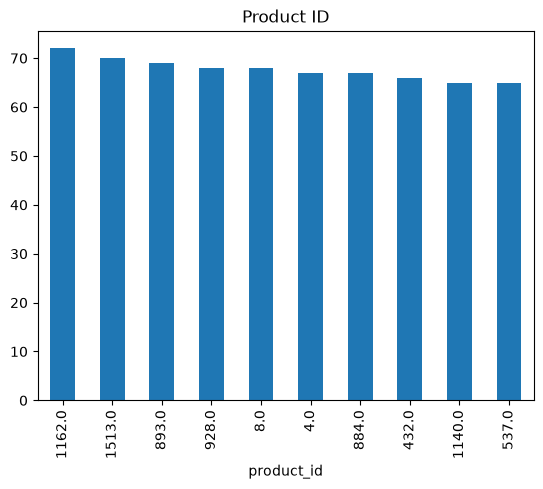

In [ ]:
transactions["product_id"].value_counts().head(10).plot(kind="bar", title="Product ID")
plt.show()

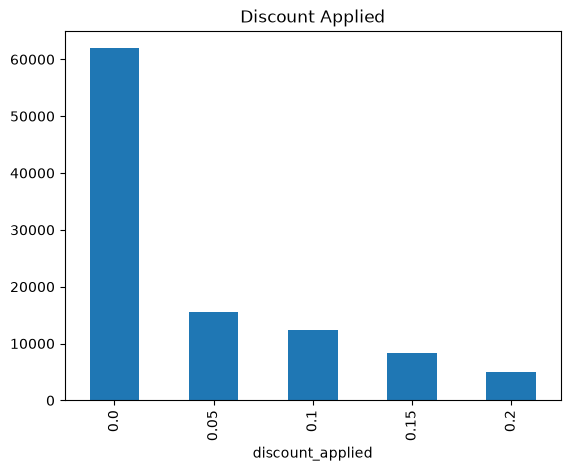

In [ ]:
transactions["discount_applied"].value_counts().plot(
    kind="bar", title="Discount Applied"
)
plt.show()

<Axes: xlabel='gross_revenue', ylabel='Count'>

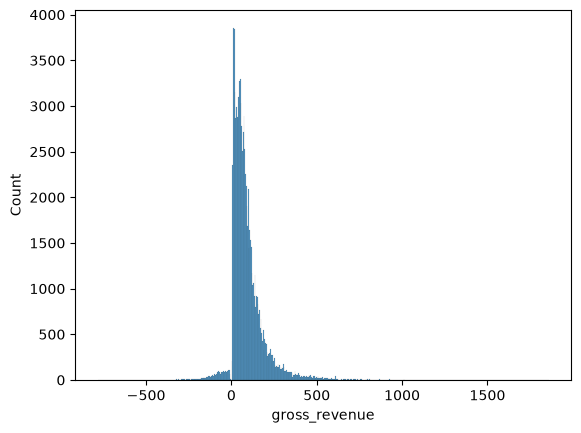

In [29]:
sns.histplot(data=transactions, x="gross_revenue")

In [4]:
transactions["gross_revenue"].describe()

count    92678.000000
mean        90.355493
std        100.684683
min       -783.040000
25%         34.240000
50%         68.000000
75%        117.617500
max       1858.320000
Name: gross_revenue, dtype: float64

In [ ]:
(transactions["gross_revenue"] < 0).sum()

np.int64(2704)

In [13]:
transactions.loc[transactions["gross_revenue"] < 0]

,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
11,12,2021-04-04 21:06:51,69122,781.0,1,0.20,-97.41,30,1
19,20,2023-07-31 13:11:49,30583,899.0,1,0.00,-176.65,4,1
87,88,2023-01-25 20:28:58,42213,1709.0,1,0.10,-46.32,9,1
169,170,2023-04-10 19:53:23,12388,154.0,2,0.10,-85.23,8,1
249,250,2023-07-02 06:12:13,56791,732.0,1,0.05,-121.87,49,1
...,...,...,...,...,...,...,...,...,...
102985,102986,2023-11-27 10:07:29,78507,869.0,1,0.00,-146.36,31,1
102994,102995,2022-01-09 11:23:50,64955,463.0,2,0.00,-46.44,40,1
103069,103070,2022-03-01 13:44:11,31971,34.0,1,0.00,-58.08,4,1
103086,103087,2021-09-11 17:30:09,29151,900.0,1,0.00,-106.95,0,1


In [33]:
(transactions["refund_flag"] == 1).sum()

np.int64(3029)

In [ ]:
transactions.loc[
    (transactions["gross_revenue"] < 0) & (transactions["refund_flag"] == 0)
]

,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag


In [ ]:
transactions.loc[
    (transactions["refund_flag"] == 1) & (transactions["gross_revenue"] >= 0)
]

,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag


In [ ]:
refund = transactions.loc[transactions["refund_flag"] == 1].iloc[0]

transactions.loc[
    (transactions["customer_id"] == refund["customer_id"])
    & (transactions["product_id"] == refund["product_id"])
].sort_values("timestamp")

,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
11,12,2021-04-04 21:06:51,69122,781.0,1,0.2,-97.41,30,1


In [ ]:
refunds = transactions.loc[
    transactions["refund_flag"] == 1,
    [
        "transaction_id",
        "customer_id",
        "product_id",
        "timestamp",
        "quantity",
        "gross_revenue",
    ],
].copy()

purchases = transactions.loc[
    transactions["refund_flag"] == 0,
    [
        "transaction_id",
        "customer_id",
        "product_id",
        "timestamp",
        "quantity",
        "gross_revenue",
    ],
].copy()

refunds["timestamp"] = pd.to_datetime(refunds["timestamp"])
purchases["timestamp"] = pd.to_datetime(purchases["timestamp"])

matched = refunds.merge(
    purchases,
    on=["customer_id", "product_id"],
    how="left",
    suffixes=("_refund", "_purchase"),
)

matched["purchase_before_refund"] = (
    matched["timestamp_purchase"] < matched["timestamp_refund"]
)

In [28]:
matched["purchase_before_refund"].value_counts()

purchase_before_refund
False    3013
True       18
Name: count, dtype: int64

In [ ]:
refund_has_prior_purchase = matched.groupby("transaction_id_refund")[
    "purchase_before_refund"
].any()

refund_has_prior_purchase.value_counts()

purchase_before_refund
False    3011
True       18
Name: count, dtype: int64

In [ ]:
total_revenue = transactions["gross_revenue"].sum()

sales_only = transactions.loc[transactions["refund_flag"] == 0, "gross_revenue"].sum()

refund_total = transactions.loc[transactions["refund_flag"] == 1, "gross_revenue"].sum()

print(f"Total revenue: {total_revenue:,.2f}")
print(f"Sales only: {sales_only:,.2f}")
print(f"Refund total: {refund_total:,.2f}")

Total revenue: 8,373,966.36
Sales only: 8,630,269.31
Refund total: -256,302.95


In [5]:
(transactions["gross_revenue"] == 0).sum()

np.int64(0)

In [6]:
transactions["gross_revenue"].isna().sum()

np.int64(10449)

In [ ]:
(transactions["gross_revenue"].isna().mean() * 100).round(2)

np.float64(10.13)

In [ ]:
transactions.loc[transactions["gross_revenue"].isna()]

,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
15,16,2021-02-13 07:36:17,33154,NaN,1,0.05,NaN,29,0
20,21,2023-03-29 19:49:38,52652,NaN,1,0.00,NaN,40,0
21,22,2021-08-01 15:47:25,30425,NaN,1,0.15,NaN,49,0
55,56,2023-06-13 04:11:11,1280,NaN,3,0.15,NaN,0,0
57,58,2022-07-23 20:38:49,32032,NaN,1,0.05,NaN,13,0
...,...,...,...,...,...,...,...,...,...
103042,103043,2021-11-21 10:13:36,97202,NaN,1,0.20,NaN,0,0
103066,103067,2023-06-09 08:45:34,22073,NaN,1,0.10,NaN,39,0
103096,103097,2022-01-05 02:47:16,44512,NaN,1,0.00,NaN,25,0
103098,103099,2021-10-22 19:40:52,16471,NaN,1,0.00,NaN,28,0


In [ ]:
transactions.loc[
    transactions["gross_revenue"].isna(), ["product_id", "gross_revenue", "refund_flag"]
]

,product_id,gross_revenue,refund_flag
15,NaN,NaN,0
20,NaN,NaN,0
21,NaN,NaN,0
55,NaN,NaN,0
57,NaN,NaN,0
...,...,...,...
103042,NaN,NaN,0
103066,NaN,NaN,0
103096,NaN,NaN,0
103098,NaN,NaN,0


In [ ]:
(transactions["gross_revenue"].isna() == transactions["product_id"].isna()).all()

np.True_

In [4]:
transactions.nlargest(10, "gross_revenue")

,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
63771,63772,2023-11-27 16:53:44,72115,496.0,4,0.00,1858.32,0,0
89725,89726,2022-01-15 13:08:00,11800,496.0,4,0.00,1858.32,25,0
39714,39715,2021-04-29 20:59:11,67585,223.0,4,0.00,1597.44,27,0
8709,8710,2023-10-10 16:18:32,93869,496.0,4,0.15,1579.57,44,0
53552,53553,2023-07-22 19:59:22,31613,496.0,3,0.00,1393.74,12,0
57523,57524,2021-09-28 02:07:00,54135,496.0,3,0.00,1393.74,24,0
83270,83271,2022-05-03 19:52:31,62544,496.0,3,0.10,1254.37,34,0
58001,58002,2021-11-24 18:57:18,21602,1185.0,4,0.00,1224.76,2,0
15135,15136,2023-10-26 19:04:38,34218,1590.0,4,0.00,1207.32,16,0
95975,95976,2021-05-09 17:34:42,30826,1590.0,4,0.00,1207.32,7,0


In [ ]:
transactions.nlargest(10, "gross_revenue").merge(products, on="product_id", how="left")

,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag,category,brand,base_price,launch_date,is_premium
0,63772,2023-11-27 16:53:44,72115,496.0,4,0.00,1858.32,0,0,Electronics,Brand_16,464.58,2022-10-31,1
1,89726,2022-01-15 13:08:00,11800,496.0,4,0.00,1858.32,25,0,Electronics,Brand_16,464.58,2022-10-31,1
2,39715,2021-04-29 20:59:11,67585,223.0,4,0.00,1597.44,27,0,Electronics,Brand_6,399.36,2023-02-22,1
3,8710,2023-10-10 16:18:32,93869,496.0,4,0.15,1579.57,44,0,Electronics,Brand_16,464.58,2022-10-31,1
4,53553,2023-07-22 19:59:22,31613,496.0,3,0.00,1393.74,12,0,Electronics,Brand_16,464.58,2022-10-31,1
5,57524,2021-09-28 02:07:00,54135,496.0,3,0.00,1393.74,24,0,Electronics,Brand_16,464.58,2022-10-31,1
6,83271,2022-05-03 19:52:31,62544,496.0,3,0.10,1254.37,34,0,Electronics,Brand_16,464.58,2022-10-31,1
7,58002,2021-11-24 18:57:18,21602,1185.0,4,0.00,1224.76,2,0,Electronics,Brand_80,306.19,2021-04-14,1
8,15136,2023-10-26 19:04:38,34218,1590.0,4,0.00,1207.32,16,0,Home,Brand_70,301.83,2023-01-01,1
9,95976,2021-05-09 17:34:42,30826,1590.0,4,0.00,1207.32,7,0,Home,Brand_70,301.83,2023-01-01,1


In [6]:
transactions["quantity"].value_counts().sort_index()

quantity
1    77352
2    15327
3     7324
4     3124
Name: count, dtype: int64

In [8]:
transactions["customer_id"].isin(customers["customer_id"]).all()

np.True_

In [9]:
transactions["product_id"].dropna().isin(products["product_id"]).all()

np.True_

In [10]:
transactions["campaign_id"].isin(campaigns["campaign_id"]).all()

np.False_

In [11]:
set(transactions["campaign_id"].unique()) - set(campaigns["campaign_id"].unique())

{np.int64(0)}

In [ ]:
transactions_campaigns = transactions.merge(
    campaigns[["campaign_id", "start_date", "end_date"]], on="campaign_id", how="left"
)

In [14]:
campaign_transactions = transactions_campaigns.loc[
    transactions_campaigns["campaign_id"] != 0
].copy()

In [ ]:
before_mask = campaign_transactions["timestamp"] < campaign_transactions["start_date"]

during_mask = campaign_transactions["timestamp"].between(
    campaign_transactions["start_date"], campaign_transactions["end_date"]
)

after_mask = campaign_transactions["timestamp"] > campaign_transactions["end_date"]

In [ ]:
pd.Series(
    {
        "Before campaign": before_mask.mean() * 100,
        "During campaign": during_mask.mean() * 100,
        "After campaign": after_mask.mean() * 100,
    }
).round(2)

Before campaign    49.57
During campaign     4.87
After campaign     45.55
dtype: float64

### Transaction Table Overview

### Table Summary 

**Rows:** 103,127
**Columns:** 9
**Primary Key:** `transaction_id`
**Foreign Keys:** `customer_id`, `product_id`, `campaign_id`

### Columns Summary

- `transaction_id` : Unique identifier for each transaction
- `timestamp` : Transaction timestamp (2021-01-01 to 2023-12-31)
- `customer_id` : Foreign key to the `customers` table
- `product_id` : Foreign key to the `products` table
- `quantity` : Number of items purchased (1-4)
- `discount_applied` : 0%, 5%, 10%, 15%, 20%
- `gross_revenue` : -$783.04 to $1858.32
- `campaign_id` : Marketing campaign associated with the transaction
- `refund_flag` : Indicates whether the transaction is a refund (0 = No, 1 = Yes).

### Data Types
- `timestamp` is stored as an object and will be converted to a datetime during data cleaning.
- All remaining columns have appropriate data types.

### Missing Values 
- Missing values are present in product_id and gross_revenue
- Every record with a missing product_id also had a missing gross_revenue and vice-versa
- These missing values affect approximately 10% of transactions.

#### Duplicates
- All 103,127 transaction_id values are unique.
- No duplicate transaction records were identified.

### Discount Applied
- Transactions without a discount are recorded as 0% rather than missing values.
- The most common discount after 0% is 5%, suggesting this is the standard promotional discount used in the dataset.

### Product Coverage
- The table contains transactions for 2,000 unique products, matching the number of products in the products table.

### Gross Revenue
- Mean: $90
- Median: $68
- Range: $783 - $1858
- No transactions have a gross revenue of $0.
- The highest-value transactions appear legitimate. After joining with the products table, they were found to correspond to high-priced electronic products rather than data quality issues.

### Refunds
- **2,704** transactions have a negative `gross_revenue`.
- Every transaction with a negative `gross_revenue` is flagged as a refund.
- All refund transactions have a negative `gross_revenue`, indicating consistency between these two fields.
- However, only **18** of the **3,029** refund transactions could be matched to an earlier purchase by the same customer and product.
- This suggests that refund transactions were generated independently rather than representing reversals of previous purchases.
- Consequently, summing `gross_revenu` across all transactions may underestimate total revenue. Revenue analyses should either exclude refund transactions or clearly distinguish between sales and refund records.

### Referential Integrity
- The `customer_id` and `product_id` foreign keys successfully reference valid records in the `customers` and `products` tables.
- The `campaign_id` foreign key initially failed validation because some transactions contain a value of **0**, which does not exist in the `campaigns` table.
- Similar to the `events` table, `campaign_id = 0` represents transactions that are not associated with a marketing campaign rather than invalid records.
- Excluding this placeholder value, all remaining `campaign_id` values successfully reference valid campaigns.

### Camapign Date Validation
- Transaction timestamps were compared against the start and end dates of their associated marketing campaigns.
- Similar to the events table, only **4.87%** of campaign-linked transactions occurred during the recorded campaign period, while **49.57%** occurred before the campaign started and **45.55%** occurred after it ended.
- This suggests that campaign identifiers and transaction timestamps were generated independently rather than representing actual campaign attribution.

### Table Conclusion

The `transaction`s table is generally well structured, with unique transaction identifiers, valid foreign key relationships (excluding the documented `campaign_id = 0` placeholder), and internally consistent refund indicators. However, the synthetic nature of the dataset introduces limitations, including independently generated refund records and campaign timestamps that are largely inconsistent with campaign durations. Despite these limitations, the table remains suitable for analyses of purchasing behavior, pricing, discounts, product performance, and customer transactions, provided these documented constraints are considered.


## Data Quality Summary

### Date Cleaning Required
- Convert timestamps to datetime
- Standardize traffic source capitalization
- Remove incomplete transactions with missing product and revenue
- Create a forign key match for no campaign between fact tables and campaign dimension table

### Dataset Limitations
- Campaign dates do not align with event/transaction timestamps (~95% affected)
- Refunds are independent negative revenue records with no link to original purchases
- Session IDs do not reliably represent user sessions

### Analysis Decisions
- Campaign date ranges will not be used for performance analysis.
- Refunds will be treated as revenue adjustments.
- Session-level metrics will not be included.
- Campaigns will instead be analyzed by channel, objective, and target segment.

In [12]:
# Customers
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

# Campaigns
campaigns["start_date"] = pd.to_datetime(campaigns["start_date"])
campaigns["end_date"] = pd.to_datetime(campaigns["end_date"])

# Products
products["launch_date"] = pd.to_datetime(products["launch_date"])

# Events
events["timestamp"] = pd.to_datetime(events["timestamp"])

# Transactions
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])